# Case I Depth Comparisons

This notebook reproduces the Case I network-depth comparisons. We first load the fixed Case I data and model catalogue, then sweep the depth of the diffusion and density networks while holding the remaining architecture fixed.

The notebook contains:

1. A diffusion-network depth sweep over $L_D \in \{2, 3, 4\}$ at fixed $W_u = 64$,  $L_u = 3$ and $ES = 2000$, reported across several diffusion widths $W_D \in \{1,2,4\}$.
2. A density-network depth sweep over $L_u \in \{2, 3, 4\}$ at fixed $W_D = 2$, $L_D = 3$, and $ES = 2000$, reported across several density widths $W_u  \in \{32,64,128\}$.

*It produces plots for Fig. 6 in the paper.*


## Setup

Load the plotting helpers together with the saved BINN wrapper classes required to unpickle trained checkpoints.


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import sympy as sp
import torch

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_data import build_catalog, load_data_object, load_original_data
from Training.JN.notebook_helpers.notebook_config import (
    BCbool,
    BNdataLossFuncLabel,
    D_one_param_bool,
    binn_batch_size,
    binn_lr,
    binn_model_num,
    binn_rel_save_thresh,
    binn_rel_update_thresh,
    binnDevice,
    binnGenerateIndicesLabel,
    binnVF,
)
from Training.JN.notebook_helpers.notebook_models import (
    active_constraint_settings,
    build_model_catalog,
    filter_model_catalog,
    resolve_model_path_from_catalog,
)
from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals

paths = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = paths.project_root
JN_ROOT = paths.notebook_root
DATA_ROOT = paths.data_root
BINN_ROOT = paths.binn_root

register_notebook_pickle_globals()

data_orig_obj_FKPP = load_original_data(DATA_ROOT)

from paper_helpers import (
    condense_df,
    scale_function_by_percent_error,
    plot_eval_D_multi_gray,
    plot_final_loss_lst,
    plot_initial_condition_1d,
    plot_total_run_times_lst,
)


## 1. Load the Case I data

We first recover the simulated reaction-diffusion dataset used throughout the notebook, then verify that the corresponding saved data object exists on disk before any model comparisons begin. The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462)

MSE between u and u_clean: 0.0
ABS between u and u_clean [cells]: 0.0
ABS (%) between u and u_clean: 0.0


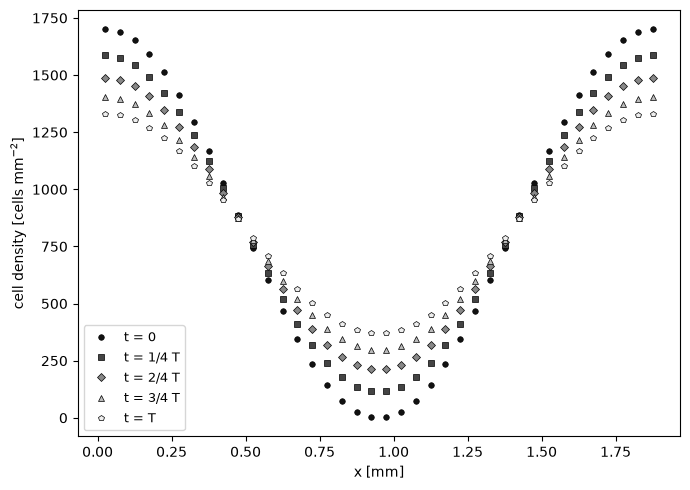

In [2]:
x = data_orig_obj_FKPP.x
t = data_orig_obj_FKPP.t
K = 1

data_df = build_catalog(DATA_ROOT, target_filename="data_obj.npy")

CASE1_DATA_CONFIG = {
    "dataX1num": len(x),
    "dataX2num": 1,
    "dataTnum": len(t),
    "dataK": K,
    "dataICLabel": "cos",
    "dataDiffLabel": "const",
    "dataGrowLabel": "zero",
    "dataGamma": 0,
    "dataNoisePercent": 0,
    "dataNoiseSeed": 0,
}

data_obj, case1_data_catalog = load_data_object(CASE1_DATA_CONFIG, DATA_ROOT, data_df=data_df)
plot_initial_condition_1d(data_obj)


## 2. Build the Case I model catalogue & form helper functions for model loading and plotting

### 2.1. Catalogue trained model

Next we catalogue all saved BINN checkpoints under `Training/binn`, filter them to the fixed Case I assumptions, and display the subset that should support the depth sweeps below.


In [3]:
binn_df = build_model_catalog(BINN_ROOT)

ALL_CONSTRAINTS = True
CONSTRAINT_TUPLE = (True, True, False, False)
CONSTRAINT_WEIGHTS = {
    "D_bound_weight": 0,
    "D_mono_weight": 1e1,
    "G_bound_weight": 1e4,
    "G_mono_weight": 1e4,
}
CONSTRAINT_BOUNDS = {
    "D_bound": (0, 0.1),
    "G_bound": (-0.02 / (1 / 24), 0.1 / (1 / 24)),
}
NOTE_DEPTH_NUM_PDE_SAMPLES = 1000
FIXED_G_WIDTH = None

DEFAULT_BINN_ACTIVATION = "silu"
DEFAULT_SURFACE_HIDDEN_LAYERS = 3
DEFAULT_DG_HIDDEN_LAYERS = 3
DEFAULT_PERFECT_PDE = False
DEFAULT_SPLIT_SEEDS = [0, 1, 2]

CASE1_FIXED_FILTERS = CASE1_DATA_CONFIG | {
    "binnVF": binnVF,
    "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
    "binnGsize": FIXED_G_WIDTH,
    "DoneParamBool": D_one_param_bool,
    "binnDevice": binnDevice,
    "allConstraints": ALL_CONSTRAINTS,
    "BCbool": BCbool,
    "numPDEsamples": NOTE_DEPTH_NUM_PDE_SAMPLES,
    "binnLR": binn_lr,
    "binnBatchSize": binn_batch_size,
    "binnRelUpdateThresh": binn_rel_update_thresh,
    "binnRelSaveThresh": binn_rel_save_thresh,
    "BNdataLossFuncLabel": BNdataLossFuncLabel,
}
if ALL_CONSTRAINTS:
    CASE1_FIXED_FILTERS |= active_constraint_settings(
        CONSTRAINT_TUPLE,
        CONSTRAINT_WEIGHTS,
        CONSTRAINT_BOUNDS,
    )

case1_catalog = filter_model_catalog(
    binn_df,
    CASE1_FIXED_FILTERS,
    empty_message="No BINN models were found for the fixed Case I assumptions in this notebook.",
)

sort_columns = [
    column
    for column in [
        "binnES",
        "binnDsize",
        "binnUsize",
        "binnTVsplitSeed",
        "binnSurfaceHiddenLayers",
        "binnDGHiddenLayers"
    ]
    if column in case1_catalog.columns
]
case1_catalog = case1_catalog.sort_values(sort_columns).reset_index(drop=True)

catalog_columns = [
    column
    for column in [
        "binnES",
        "binnDsize",
        "binnUsize",
        "binnTVsplitSeed",
        "binnSurfaceHiddenLayers",
        "binnDGHiddenLayers",
        "full_path",
    ]
    if column in case1_catalog.columns
]
case1_catalog[catalog_columns]


,binnES,binnDsize,binnUsize,binnTVsplitSeed,binnSurfaceHiddenLayers,binnDGHiddenLayers,full_path
0,1000,2,128,0,NaN,NaN,/Users/willa954/Desktop/Git-personal/Hyperpara...
1,1000,2,128,0,NaN,NaN,/Users/willa954/Desktop/Git-personal/Hyperpara...
2,1000,2,128,0,NaN,NaN,/Users/willa954/Desktop/Git-personal/Hyperpara...
3,1000,2,128,1,NaN,NaN,/Users/willa954/Desktop/Git-personal/Hyperpara...
4,1000,2,128,1,NaN,NaN,/Users/willa954/Desktop/Git-personal/Hyperpara...
...,...,...,...,...,...,...,...
196,3000,2,8,1,NaN,NaN,/Users/willa954/Desktop/Git-personal/Hyperpara...
197,3000,2,8,1,NaN,NaN,/Users/willa954/Desktop/Git-personal/Hyperpara...
198,3000,2,8,2,NaN,NaN,/Users/willa954/Desktop/Git-personal/Hyperpara...
199,3000,2,8,2,NaN,NaN,/Users/willa954/Desktop/Git-personal/Hyperpara...


### 2.2. Helper functions for loading trained models

### 2.3 Shared plotting style

Small loaders retrieve the exact trained checkpoints for each depth experiment, and a consistent formatting is defined for all depth-comparison figures together with the reference diffusion levels used in the MSE panels.


In [4]:
BLUE_COLORS = ["#0033A0", "#1E90FF", "#6699CC", "#A4C8E1", "#D6EAF8"]
D_COLORS = ["#8B2500", "#FF7F0E", "#FDB863", "#FDD9B5", "#FFF1E0"]
linestyles = ["-"] * 5
MARKER_STYLES = ["o"] * 5
HATCH_PATTERNS = ("////", "....", "ooo", "***")
AXIS_FONTSIZES = {
    "xaxis": 18,
    "xtick_labels": 18,
    "yaxis": 18,
    "ytick_labels": 18,
}
LEGEND_SIZE = 18

def plot_params_for_values(values, colors):
    return {
        value: [colors[i], linestyles[i], MARKER_STYLES[i], f"{value}"]
        for i, value in enumerate(values)
    }


def ground_truth_diffusion(u):
    return data_obj.theta_D * np.ones_like(u)


rawMSEs = [0.25, 0.5, 1]
mses = [scale_function_by_percent_error(ground_truth_diffusion, beta=mse)[1] for mse in rawMSEs]
GROUND_TRUTH_DIFFUSION_SYMBOL = sp.Float(float(np.asarray(data_obj.theta_D).reshape(-1)[0]))

def load_model_wrapper_from_path(file_path, device="cpu"):
    model_wrapper = torch.load(file_path, map_location=device, weights_only=False)
    if hasattr(model_wrapper, "load_best_val"):
        model_wrapper.load_best_val(device=device)
    return model_wrapper


def build_case1_model_path(filters):
    return resolve_model_path_from_catalog(
        case1_catalog,
        CASE1_FIXED_FILTERS,
        filters,
        model_label=binn_model_num,
    )


def load_case1_model(filters, device="cpu"):
    file_path = build_case1_model_path(filters)
    if not file_path.exists():
        raise FileNotFoundError(
            "Missing Case I BINN model at expected path: "
            f"{file_path}"
        )
    return load_model_wrapper_from_path(file_path, device=device)


def make_case1_output_dir(*parts):
    output_dir = JN_ROOT / "pngs" / "1D" / "case1"
    for part in parts:
        output_dir = output_dir / str(part)
    os.makedirs(output_dir, exist_ok=True)
    return output_dir


## 3. Sweep A: vary diffusion-network depth $L_D$ at fixed $W_u = 64$

Compare $L_D \in \{2, 3, 4\}$ while fixing $W_u = 64, L_u=3$ and $ES = 2000$. The bar plots treat diffusion width $W_D$ as the grouping variable, and the density-space panel shows how the learned diffusion law changes with depth for one $W_D$.


In [5]:
def add_depth_optional_architecture_keys(info, dg_hidden_layers):
    updated = dict(info)
    if not (
        depth_compare_surface_hidden_layers == DEFAULT_SURFACE_HIDDEN_LAYERS
        and dg_hidden_layers == DEFAULT_DG_HIDDEN_LAYERS
    ):
        updated["binnSurfaceHiddenLayers"] = depth_compare_surface_hidden_layers
        updated["binnDGHiddenLayers"] = dg_hidden_layers
    return updated


def build_depth_base_filters(dg_hidden_layers):
    filters = {
        "dataX1num": len(x),
        "dataX2num": 1,
        "dataTnum": len(t),
        "dataK": K,
        "dataICLabel": "cos",
        "dataDiffLabel": "const",
        "dataGrowLabel": "zero",
        "dataGamma": 0,
        "dataNoisePercent": 0,
        "dataNoiseSeed": 0,
        "binnVF": binnVF,
        "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
        "DoneParamBool": D_one_param_bool,
        "binnDevice": binnDevice,
        "BCbool": BCbool,
        "numPDEsamples": NOTE_DEPTH_NUM_PDE_SAMPLES,
        "binnLR": binn_lr,
        "binnBatchSize": binn_batch_size,
        "binnRelUpdateThresh": binn_rel_update_thresh,
        "binnRelSaveThresh": binn_rel_save_thresh,
        "BNdataLossFuncLabel": BNdataLossFuncLabel,
        "binnGsize": FIXED_G_WIDTH,
        "allConstraints": ALL_CONSTRAINTS,
    }
    if ALL_CONSTRAINTS:
        filters["constraintTuple"] = CONSTRAINT_TUPLE
        filters.update({
            key: CONSTRAINT_WEIGHTS[key]
            for enabled, key in zip(
                CONSTRAINT_TUPLE,
                ("D_bound_weight", "D_mono_weight", "G_bound_weight", "G_mono_weight"),
            )
            if enabled
        })
        filters.update({
            key: CONSTRAINT_BOUNDS[key]
            for enabled, key in zip(
                CONSTRAINT_TUPLE,
                ("D_bound", None, "G_bound", None),
            )
            if enabled and key is not None
        })
    return add_depth_optional_architecture_keys(filters, dg_hidden_layers)


def depth_specific_case1_df(dg_hidden_layers):
    depth_df = condense_df(binn_df, build_depth_base_filters(dg_hidden_layers))
    if depth_df.empty:
        raise FileNotFoundError(
            f"No Case I BINN models found for binnDGHiddenLayers={dg_hidden_layers}."
        )
    return depth_df.reset_index(drop=True)


def build_depth_case1_fixed_binn_info(dg_hidden_layers):
    fixed_info = {
        "dataX1num": len(x),
        "dataX2num": 1,
        "dataTnum": len(t),
        "dataK": K,
        "dataICLabel": "cos",
        "dataDiffLabel": "const",
        "dataGrowLabel": "zero",
        "dataGamma": 0,
        "dataNoisePercent": 0,
        "dataNoiseSeed": 0,
        "binnVF": binnVF,
        "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
        "DoneParamBool": D_one_param_bool,
        "binnDevice": binnDevice,
        "BCbool": BCbool,
        "numPDEsamples": NOTE_DEPTH_NUM_PDE_SAMPLES,
        "binnLR": binn_lr,
        "binnBatchSize": binn_batch_size,
        "binnRelUpdateThresh": binn_rel_update_thresh,
        "binnRelSaveThresh": binn_rel_save_thresh,
        "binnModelLabel": binn_model_num,
        "BNdataLossFuncLabel": BNdataLossFuncLabel,
        "binnGsize": FIXED_G_WIDTH,
        "allConstraints": ALL_CONSTRAINTS,
    }
    if ALL_CONSTRAINTS:
        fixed_info["constraintTuple"] = CONSTRAINT_TUPLE
        fixed_info.update({
            key: CONSTRAINT_WEIGHTS[key]
            for enabled, key in zip(
                CONSTRAINT_TUPLE,
                ("D_bound_weight", "D_mono_weight", "G_bound_weight", "G_mono_weight"),
            )
            if enabled
        })
        fixed_info.update({
            key: CONSTRAINT_BOUNDS[key]
            for enabled, key in zip(
                CONSTRAINT_TUPLE,
                ("D_bound", None, "G_bound", None),
            )
            if enabled and key is not None
        })
    return add_depth_optional_architecture_keys(fixed_info, dg_hidden_layers)


def build_depth_comparison_model_path(D_NN, ES, split_seed, dg_hidden_layers):
    return resolve_model_path_from_catalog(
        depth_specific_case1_df(dg_hidden_layers),
        build_depth_case1_fixed_binn_info(dg_hidden_layers),
        {
            "binnTVsplitSeed": split_seed,
            "binnUsize": depth_compare_u_size,
            "binnDsize": D_NN,
            "binnES": ES,
        },
        model_label=binn_model_num,
    )


All x-axis labels found (ordered): ['2', '3', '4']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/fig6/plot_b_1.png


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_final_loss.py:216: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(bool(grid), axis="y", which="both", linestyle="-", linewidth=0.5, alpha=grid_alpha)


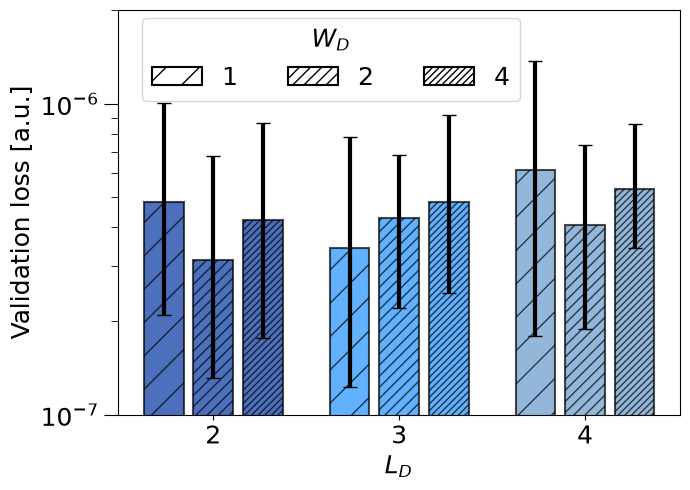

All x-axis labels found (ordered): ['2', '3', '4']
Mean runtime increases between corresponding models across groups:
  1 -> 2
    2: 1029.054s -> 1354.820s (delta +325.766s)
    3: 1079.284s -> 1076.930s (delta -2.354s)
    4: 852.858s -> 1240.150s (delta +387.292s)
    mean delta: +236.902s
  2 -> 4
    2: 1354.820s -> 1104.595s (delta -250.225s)
    3: 1076.930s -> 986.115s (delta -90.815s)
    4: 1240.150s -> 910.639s (delta -329.511s)
    mean delta: -223.517s
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/fig6/plot_b_2.png


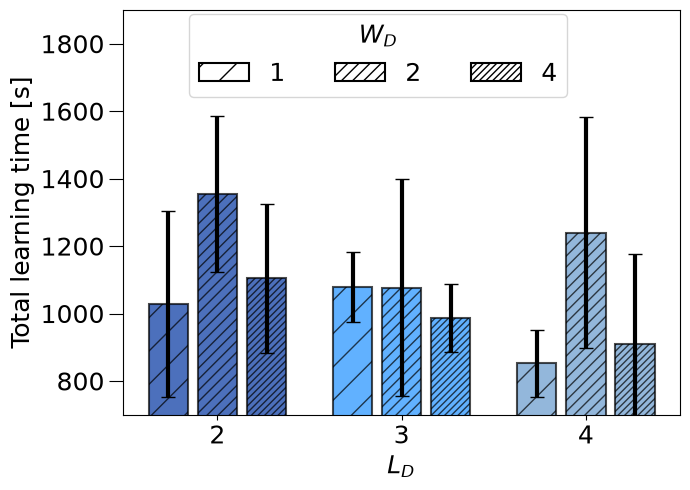

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/fig6/plot_d.png


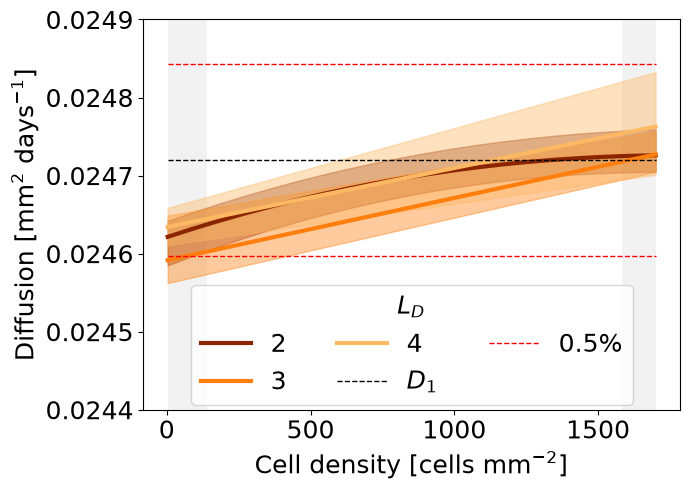

In [6]:
hatch_patterns =["/", "///", "/////"]
depth_compare_es_values = [2000]
depth_compare_u_size = 64
depth_compare_depths = [2, 3, 4]
depth_compare_d_sizes = [1,2,4]
depth_compare_split_seeds = DEFAULT_SPLIT_SEEDS
depth_compare_surface_hidden_layers = 3

depth_dir = make_case1_output_dir("fig6")


def depth_filters(D_NN, ES, split_seed, dg_hidden_layers):
    filters = {
        "binnUsize": depth_compare_u_size,
        "binnDsize": D_NN,
        "binnTVsplitSeed": split_seed,
        "binnES": ES,
    }
    if not (
        depth_compare_surface_hidden_layers == DEFAULT_SURFACE_HIDDEN_LAYERS
        and dg_hidden_layers == DEFAULT_DG_HIDDEN_LAYERS
    ):
        filters["binnSurfaceHiddenLayers"] = depth_compare_surface_hidden_layers
        filters["binnDGHiddenLayers"] = dg_hidden_layers
    return filters


def load_depth_model(D_NN, ES, split_seed, dg_hidden_layers):
    file_path = build_depth_comparison_model_path(D_NN, ES, split_seed, dg_hidden_layers)
    if not file_path.exists():
        raise FileNotFoundError(
            "Missing Wdepth comparison BINN model at expected path: "
            f"{file_path}"
        )
    return load_model_wrapper_from_path(file_path)


def load_depth_comparison_models():
    models_by_d = {}
    for D_NN in depth_compare_d_sizes:
        models_by_d[D_NN] = {}
        for ES in depth_compare_es_values:
            models_by_d[D_NN][ES] = {}
            for dg_hidden_layers in depth_compare_depths:
                seed_models = {}
                for split_seed in depth_compare_split_seeds:
                    seed_models[split_seed] = load_depth_model(
                        D_NN, ES, split_seed, dg_hidden_layers
                    )
                models_by_d[D_NN][ES][dg_hidden_layers] = seed_models
    return models_by_d


depth_models_by_d = load_depth_comparison_models()
depth_bar_plot_params = plot_params_for_values(depth_compare_depths, BLUE_COLORS)
depth_diff_bar_plot_params = plot_params_for_values(depth_compare_depths, D_COLORS)

for ES in depth_compare_es_values:
    selected_dir = depth_dir 
    os.makedirs(selected_dir, exist_ok=True)

    models_by_d_for_es = [depth_models_by_d[D_NN][ES] for D_NN in depth_compare_d_sizes]

    # First plot of second row of figure 6
    plot_final_loss_lst(
        models_by_d_for_es,
        plot_params=depth_bar_plot_params,
        label_list=[f"{D_NN}" for D_NN in depth_compare_d_sizes],
        name=str(selected_dir / "plot_b_1.png"),
        bbox_to_anchor=(0.02, 1.01),
        y_label="Validation loss [a.u.]",
        legend_size=LEGEND_SIZE,
        legend_title=r"$W_D$",
        x_label=r"$L_D$",
        figsize=(7, 5),
        legend_ncols=3,
        ylim = [1e-7, 2e-6],
        axis_fontsizes=AXIS_FONTSIZES,
        hatch_patterns=hatch_patterns
    )

    # Second plot of second row of figure 6
    plot_total_run_times_lst(
        models_dics_list=models_by_d_for_es,
        plot_params=depth_bar_plot_params,
        label_list=[f"{D_NN}" for D_NN in depth_compare_d_sizes],
        legend_pos=(0.82, 1.02),
        legend_fontsize=18,#LEGEND_SIZE,
        name=str(selected_dir / "plot_b_2.png"),
        y_label="Total learning time [s]",

        legend_title=r"$W_D$",
        x_label=r"$L_D$",
        figsize=(7, 5),
        legend_ncols=3,
        axis_fontsizes=AXIS_FONTSIZES,
        y_lim = [7e2,1.9e3],
        y_scale="linear",
        hatch_patterns=hatch_patterns
    )

selected_ES_for_depth_plot = depth_compare_es_values[-1]
selected_D_NN_for_depth_plot = 2
diffusion_models_by_depth = {
    depth: depth_models_by_d[selected_D_NN_for_depth_plot][selected_ES_for_depth_plot][depth]
    for depth in depth_compare_depths
}
diffusion_labels_by_depth = [f"{depth}" for depth in depth_compare_depths]
D_sym_true_lst_by_depth = [
    GROUND_TRUTH_DIFFUSION_SYMBOL
    for _ in diffusion_labels_by_depth
]

# Third plot of second row of figure 6
plot_eval_D_multi_gray(
    diffusion_models_by_depth,
    data_obj,
    D_sym_true_lst_by_depth,
    D_COLORS[: len(diffusion_labels_by_depth)],
    diffusion_labels_by_depth,
    Dnum=1,
    device="cpu",
    num_bins=50,
    K=1700,
    name=str(
        depth_dir
        / f"plot_d.png"
    ),
    fill=True,
    legend_pos=(0.5, 0.165),
    legend_ncols=3,
    legend_fontsize=LEGEND_SIZE,
    legend_title=r"$L_D$",
    linestyles=["-"] * len(diffusion_labels_by_depth),
    errs=[0.5, 0.5],
    figsize=(7, 5),
    axis_fontsizes=AXIS_FONTSIZES,
    ylim = [0.0244, 0.0249]
)

## 4. Sweep B: vary surface-network depth $L_u$ at fixed $W_D = 2$

Compare $L_u \in \{2, 3, 4\}$ while fixing $W_D = 2$, $L_D = 3$, and $ES = 2000$. The bar plots treat surface width $W_u$ as the grouping variable, followed by one density-space diffusion comparison at  width $W_u = 64$.


All x-axis labels found (ordered): ['2', '3', '4']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/fig6/plot_a_1.png


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_final_loss.py:216: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(bool(grid), axis="y", which="both", linestyle="-", linewidth=0.5, alpha=grid_alpha)


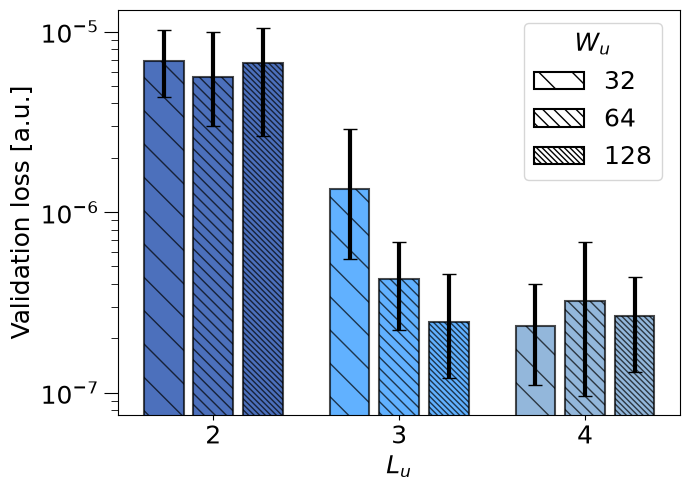

All x-axis labels found (ordered): ['2', '3', '4']
Mean runtime increases between corresponding models across groups:
  32 -> 64
    2: 506.120s -> 917.892s (delta +411.772s)
    3: 487.687s -> 1076.930s (delta +589.244s)
    4: 474.623s -> 1325.300s (delta +850.677s)
    mean delta: +617.231s
  64 -> 128
    2: 917.892s -> 1108.239s (delta +190.347s)
    3: 1076.930s -> 1739.211s (delta +662.281s)
    4: 1325.300s -> 1270.088s (delta -55.212s)
    mean delta: +265.805s
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/fig6/plot_a_2.png


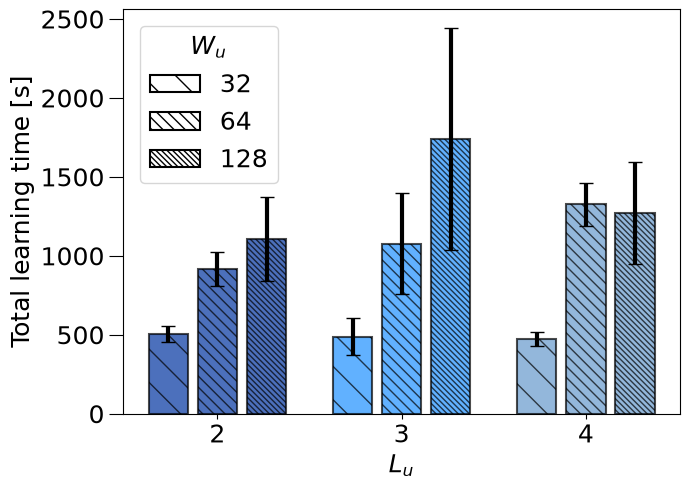

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/fig6/plot_c.png


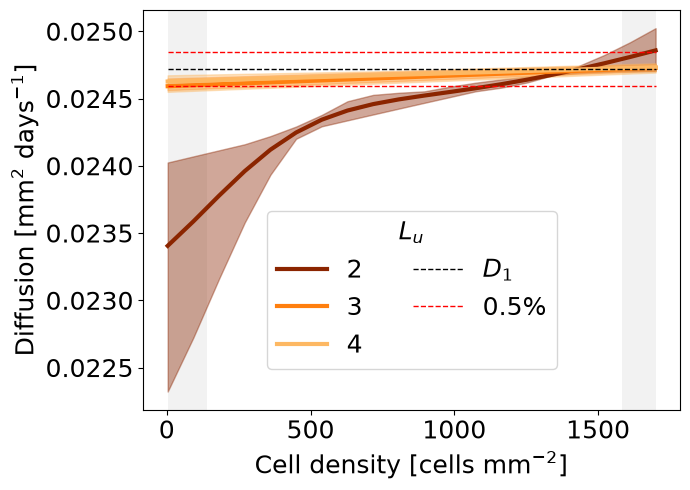

In [7]:
hatch_patterns = ("\\", "\\\\\\", "\\\\\\\\\\\\")
surface_compare_es_values = [2000]
surface_compare_u_sizes = [32, 64, 128]
surface_compare_hidden_layers = [2, 3, 4]
surface_compare_d_size = 2
surface_compare_fixed_dg_hidden_layers = 3
surface_compare_split_seeds = DEFAULT_SPLIT_SEEDS

LEGEND_SIZE = 18
AXIS_FONTSIZES = {
    "xaxis": 18,
    "xtick_labels": 18,
    "yaxis": 18,
    "ytick_labels": 18,
}

def surface_filters(u_size, ES, split_seed, surface_hidden_layers):
    filters = {
        "binnUsize": u_size,
        "binnDsize": surface_compare_d_size,
        "binnTVsplitSeed": split_seed,
        "binnES": ES,
    }
    if not (
        surface_hidden_layers == DEFAULT_SURFACE_HIDDEN_LAYERS
        and surface_compare_fixed_dg_hidden_layers == DEFAULT_DG_HIDDEN_LAYERS
    ):
        filters["binnSurfaceHiddenLayers"] = surface_hidden_layers
        filters["binnDGHiddenLayers"] = surface_compare_fixed_dg_hidden_layers
    return filters


def load_surface_comparison_models():
    models_by_u = {}
    for u_size in surface_compare_u_sizes:
        models_by_u[u_size] = {}
        for ES in surface_compare_es_values:
            models_by_u[u_size][ES] = {}
            for surface_hidden_layers in surface_compare_hidden_layers:
                seed_models = {}
                for split_seed in surface_compare_split_seeds:
                    seed_models[split_seed] = load_case1_model(
                        surface_filters(u_size, ES, split_seed, surface_hidden_layers)
                    )
                models_by_u[u_size][ES][surface_hidden_layers] = seed_models
    return models_by_u


surface_models_by_u = load_surface_comparison_models()
surface_bar_plot_params = plot_params_for_values(surface_compare_hidden_layers, BLUE_COLORS)
surface_diff_bar_plot_params = plot_params_for_values(surface_compare_hidden_layers, D_COLORS)

for ES in surface_compare_es_values:
    selected_dir = depth_dir
    os.makedirs(selected_dir, exist_ok=True)
    models_by_surface_for_es = [surface_models_by_u[u_size][ES] for u_size in surface_compare_u_sizes]

    # First plot of first row of figure 6
    plot_final_loss_lst(
        models_by_surface_for_es,
        plot_params=surface_bar_plot_params,
        label_list=[f"{u_size}" for u_size in surface_compare_u_sizes],
        name=str(selected_dir / "plot_a_1.png"),
        bbox_to_anchor=(0.7, 1.0),
        y_label="Validation loss [a.u.]",
        legend_size=LEGEND_SIZE,
        axis_fontsizes=AXIS_FONTSIZES,
        legend_title=r"$W_u$",
        x_label=r"$L_u$",
        figsize=(7, 5),
        legend_ncols=1,
        hatch_patterns=hatch_patterns,
    )
    # Second plot of first row of figure 6
    plot_total_run_times_lst(
        models_dics_list=models_by_surface_for_es,
        plot_params=surface_bar_plot_params,
        label_list=[f"{u_size}" for u_size in surface_compare_u_sizes],
        legend_pos=(0.3, 0.99),
        legend_fontsize=LEGEND_SIZE,
        axis_fontsizes=AXIS_FONTSIZES,
        name=str(selected_dir / "plot_a_2.png"),
        y_label="Total learning time [s]",
        hatch_patterns=hatch_patterns,
        legend_title=r"$W_u$",
        x_label=r"$L_u$",
        figsize=(7, 5),
        y_scale="linear",
    )
selected_ES_for_surface_plot = surface_compare_es_values[-1]
selected_u_for_surface_plot = 64
diffusion_models_by_surface = {
    surface_hidden_layers: surface_models_by_u[selected_u_for_surface_plot][selected_ES_for_surface_plot][surface_hidden_layers]
    for surface_hidden_layers in surface_compare_hidden_layers
}
diffusion_labels_by_surface = [f"{surface_hidden_layers}" for surface_hidden_layers in surface_compare_hidden_layers]
D_sym_true_lst_by_surface = [
    GROUND_TRUTH_DIFFUSION_SYMBOL
    for _ in diffusion_labels_by_surface
]

# Third plot of first row of figure 6
plot_eval_D_multi_gray(
    diffusion_models_by_surface,
    data_obj,
    D_sym_true_lst_by_surface,
    D_COLORS[: len(diffusion_labels_by_surface)],
    diffusion_labels_by_surface,
    Dnum=1,
    device="cpu",
    num_bins=50,
    K=1700,
    name=str(
    depth_dir
        / "plot_c.png"
    ),
    fill=True,
    legend_pos=(0.5, 0.3),
    legend_ncols=2,
    legend_fontsize=LEGEND_SIZE,
    legend_title=r"$L_u$",
    linestyles=["-"] * len(diffusion_labels_by_surface),
    errs=[0.5, 0.5],
    figsize=(7, 5),
    axis_fontsizes=AXIS_FONTSIZES,
)


## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
